## DESCARGAR 1ER SUJETO

In [1]:
from nilearn import datasets
import nibabel as nib

abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]
img = nib.load(fmri_path)

# Extraer TR desde el header NIfTI
TR = img.header.get_zooms()[3]
print(f"Archivo: {fmri_path}")
print(f"TR (Repetition Time): {TR} segundos")


Archivo: ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
TR (Repetition Time): 1.5 segundos


In [2]:
print(abide.keys())

dict_keys(['description', 'phenotypic', 'func_preproc'])


In [3]:
print(abide.func_preproc)

['./data\\ABIDE_pcp\\cpac\\nofilt_noglobal\\Pitt_0050003_func_preproc.nii.gz']


In [4]:
fmri_path = abide.func_preproc[0]
print(fmri_path)

./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz


In [5]:
import nibabel as nib

img = nib.load(fmri_path)
data = img.get_fdata()

print("Shape:", data.shape)

Shape: (61, 73, 61, 196)


## 4D

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Shape del volumen:", data.shape)
print("Número de dimensiones:", data.ndim)
print("Tipo:", type(data))

Shape del volumen: (61, 73, 61, 196)
Número de dimensiones: 4
Tipo: <class 'numpy.ndarray'>


In [7]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"Dimensión X: {x_dim}")
print(f"Dimensión Y: {y_dim}")
print(f"Dimensión Z: {z_dim}")
print(f"Timepoints: {t_dim}")

Dimensión X: 61
Dimensión Y: 73
Dimensión Z: 61
Timepoints: 196


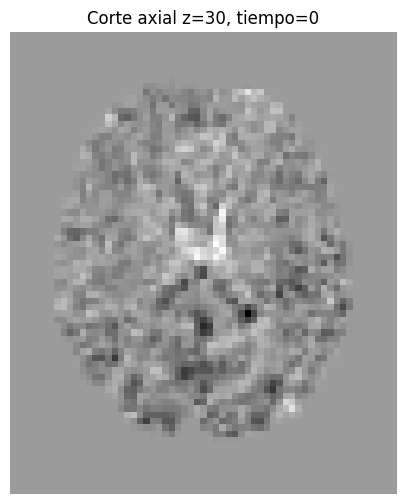

In [8]:
z = z_dim // 2

plt.figure(figsize=(6, 6))
plt.imshow(data[:, :, z, 0].T, cmap="gray", origin="lower")
plt.title(f"Corte axial z={z}, tiempo=0")
plt.axis("off")
plt.show()

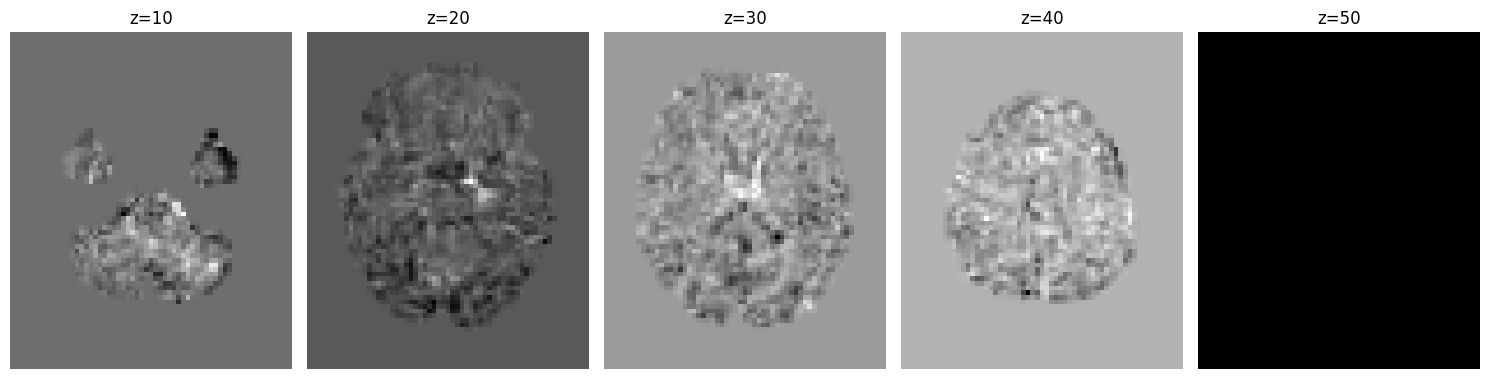

In [9]:
slices = [10, 20, 30, 40, 50]

fig, axes = plt.subplots(1, len(slices), figsize=(15, 4))

for ax, z in zip(axes, slices):
    if z < z_dim:
        ax.imshow(data[:, :, z, 0].T, cmap="gray", origin="lower")
        ax.set_title(f"z={z}")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
x = x_dim // 2
y = y_dim // 2
z = z_dim // 2

signal = data[x, y, z, :]

print("Largo de la señal:", len(signal))
print("Primeros 10 valores:")
print(signal[:10])

Largo de la señal: 196
Primeros 10 valores:
[ 15.4220426  -48.03869064 110.42695792 102.03827326 161.07197658
 122.34468818 -12.94478029  47.1026526   93.25915256  76.22823664]


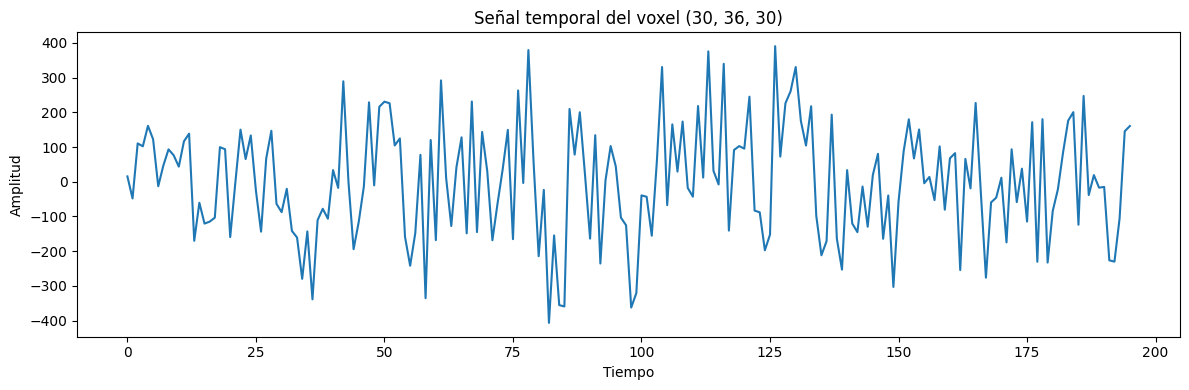

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(signal)
plt.title(f"Señal temporal del voxel ({x}, {y}, {z})")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

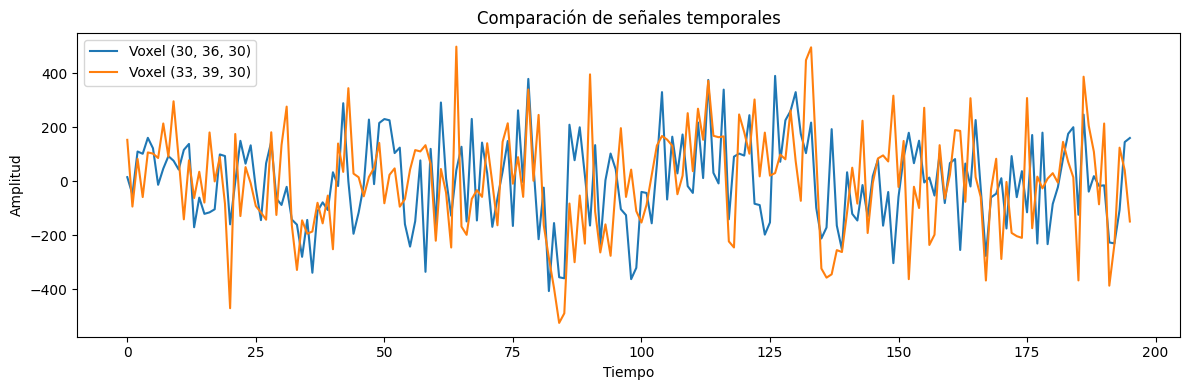

In [12]:
x1, y1, z1 = x_dim // 2, y_dim // 2, z_dim // 2
x2, y2, z2 = x_dim // 2 + 3, y_dim // 2 + 3, z_dim // 2

signal1 = data[x1, y1, z1, :]
signal2 = data[x2, y2, z2, :]

plt.figure(figsize=(12, 4))
plt.plot(signal1, label=f"Voxel ({x1}, {y1}, {z1})")
plt.plot(signal2, label=f"Voxel ({x2}, {y2}, {z2})")
plt.title("Comparación de señales temporales")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
corr = np.corrcoef(signal1, signal2)[0, 1]
print("Correlación entre ambos voxeles:", corr)

Correlación entre ambos voxeles: 0.3188608275277598


## CORTES

In [14]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [15]:
from nilearn import datasets

abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Shape:", data.shape)

Shape: (61, 73, 61, 196)


In [16]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"X: {x_dim}")
print(f"Y: {y_dim}")
print(f"Z: {z_dim}")
print(f"T: {t_dim}")

X: 61
Y: 73
Z: 61
T: 196


In [17]:
def mostrar_corte_axial(z, t=0):
    plt.figure(figsize=(6, 6))
    plt.imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    plt.title(f"Corte axial z={z}, tiempo={t}")
    plt.axis("off")
    plt.show()

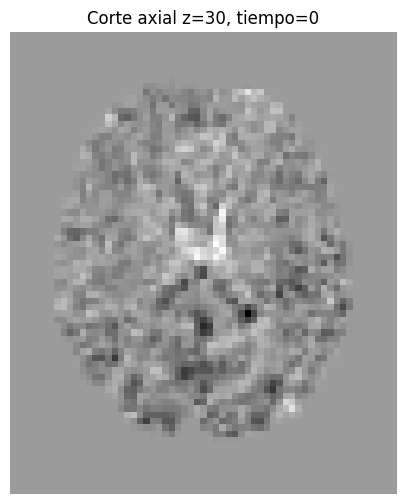

In [18]:
mostrar_corte_axial(z_dim // 2, 0)

In [19]:
slider_z = widgets.IntSlider(
    value=z_dim // 2,
    min=0,
    max=z_dim - 1,
    step=1,
    description='Slice z:'
)

widgets.interact(mostrar_corte_axial, z=slider_z, t=widgets.fixed(0))

interactive(children=(IntSlider(value=30, description='Slice z:', max=60), Output()), _dom_classes=('widget-in…

<function __main__.mostrar_corte_axial(z, t=0)>

In [20]:
slider_t = widgets.IntSlider(
    value=0,
    min=0,
    max=t_dim - 1,
    step=1,
    description='Tiempo:'
)

widgets.interact(mostrar_corte_axial, z=slider_z, t=slider_t)

interactive(children=(IntSlider(value=30, description='Slice z:', max=60), IntSlider(value=0, description='Tie…

<function __main__.mostrar_corte_axial(z, t=0)>

In [21]:
def visor_axial(z, t):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    ax.set_title(f"Corte axial z={z}, tiempo={t}")
    ax.axis("off")
    plt.show()

widgets.interact(
    visor_axial,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.IntSlider(value=0, min=0, max=t_dim - 1, step=1, description="t")
)

interactive(children=(IntSlider(value=30, description='z', max=60), IntSlider(value=0, description='t', max=19…

<function __main__.visor_axial(z, t)>

## SEÑAL


In [22]:
!pip install ipympl
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from nilearn import datasets
%matplotlib widget


In [23]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Ruta:", fmri_path)
print("Shape:", data.shape)

Ruta: ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape: (61, 73, 61, 196)


In [24]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"X: {x_dim}")
print(f"Y: {y_dim}")
print(f"Z: {z_dim}")
print(f"T: {t_dim}")

X: 61
Y: 73
Z: 61
T: 196


In [25]:
z_actual = z_dim // 2
t_actual = 0

In [26]:
def mostrar_corte_y_senal(z, t=0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    axes[1].set_title("Haz clic en la imagen")
    axes[1].set_xlabel("Tiempo")
    axes[1].set_ylabel("Amplitud")

    def onclick(event):
        if event.inaxes == axes[0] and event.xdata is not None and event.ydata is not None:
            x = int(round(event.xdata))
            y = int(round(event.ydata))

            if 0 <= x < x_dim and 0 <= y < y_dim:
                signal = data[x, y, z, :]

                axes[1].cla()
                axes[1].plot(signal)
                axes[1].set_title(f"Señal temporal voxel ({x}, {y}, {z})")
                axes[1].set_xlabel("Tiempo")
                axes[1].set_ylabel("Amplitud")

                axes[0].cla()
                axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
                axes[0].scatter(x, y, c="red", s=50)
                axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
                axes[0].set_xlabel("X")
                axes[0].set_ylabel("Y")

                fig.canvas.draw()

                print(f"Voxel seleccionado: x={x}, y={y}, z={z}")

    fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show()

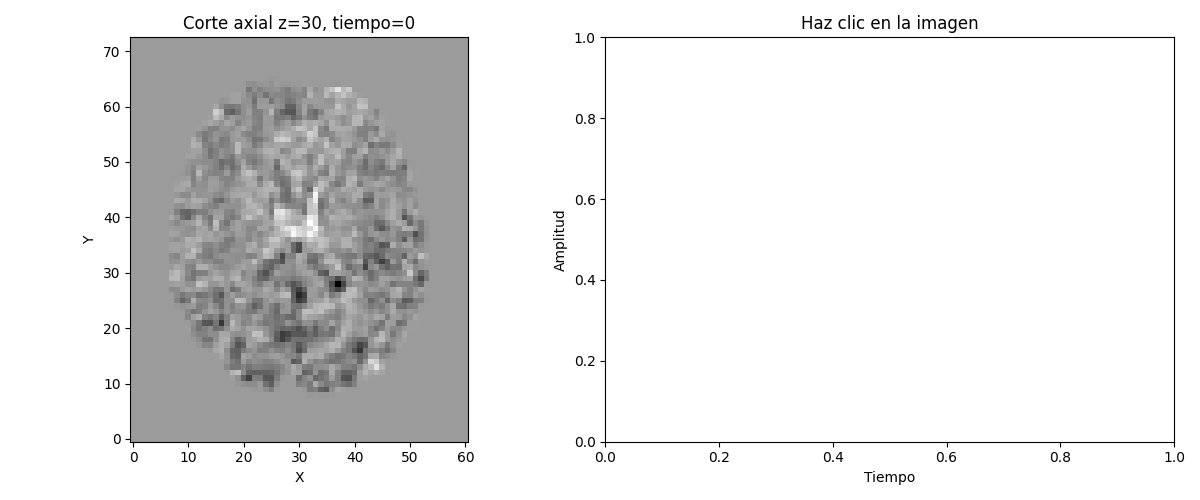

In [27]:
mostrar_corte_y_senal(z=z_dim // 2, t=0)

In [28]:
widgets.interact(
    mostrar_corte_y_senal,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.fixed(0)
)

interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

<function __main__.mostrar_corte_y_senal(z, t=0)>

In [29]:
widgets.interact(
    mostrar_corte_y_senal,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.IntSlider(value=0, min=0, max=t_dim - 1, step=1, description="t")
)

interactive(children=(IntSlider(value=30, description='z', max=60), IntSlider(value=0, description='t', max=19…

<function __main__.mostrar_corte_y_senal(z, t=0)>

## FILTRADO DE SEÑAL

Filtro pasa-banda (0.01–0.1 Hz) estándar para fMRI en reposo. Se muestra la señal original vs filtrada al hacer clic en un voxel.

In [30]:
from scipy.signal import butter, filtfilt
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from nilearn import datasets
%matplotlib widget


In [31]:
# Cargar datos (reutiliza si ya están en memoria)
try:
    data
    TR
    print(f'Datos ya cargados. Shape: {data.shape}, TR={TR}s')
except NameError:
    abide = datasets.fetch_abide_pcp(
        data_dir='./data',
        n_subjects=1,
        pipeline='cpac',
        band_pass_filtering=False,
        global_signal_regression=False,
        derivatives=['func_preproc']
    )
    fmri_path = abide.func_preproc[0]
    img = nib.load(fmri_path)
    data = img.get_fdata()
    TR = img.header.get_zooms()[3]
    print(f'Datos cargados. Shape: {data.shape}, TR={TR}s')

x_dim, y_dim, z_dim, t_dim = data.shape


Datos ya cargados. Shape: (61, 73, 61, 196), TR=1.5s


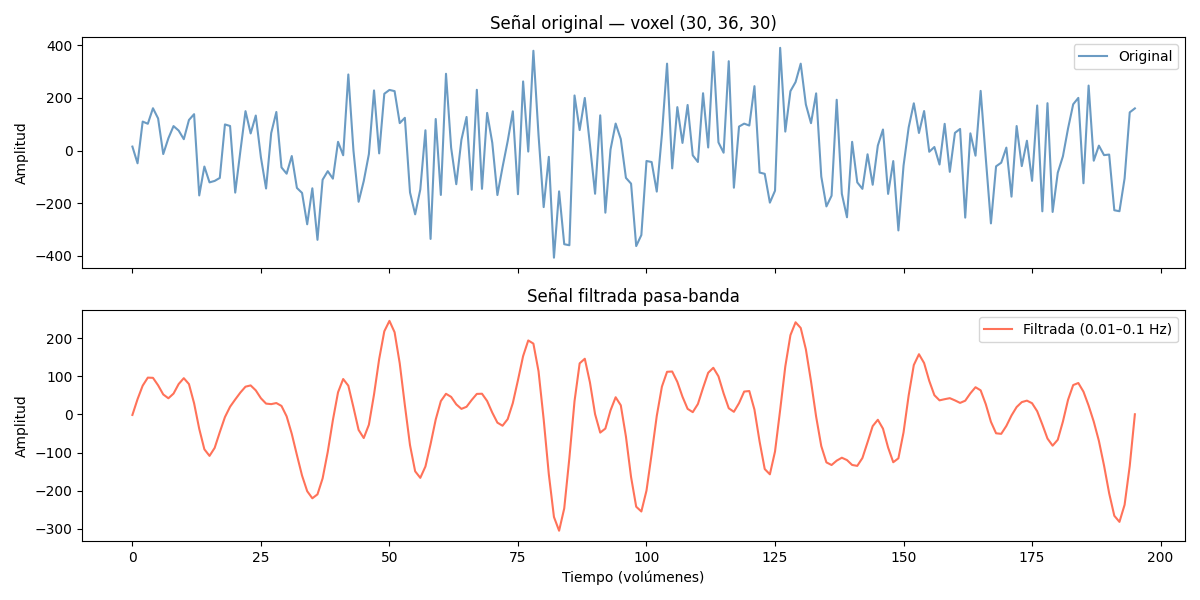

In [32]:
def bandpass_filter(signal, lowcut=0.01, highcut=0.1, tr=2.0):
    """
    Filtro pasa-banda Butterworth de orden 4.
    lowcut / highcut en Hz. tr es el Repetition Time en segundos.
    """
    fs = 1.0 / tr
    nyq = fs / 2.0
    low = lowcut / nyq
    high = highcut / nyq
    # Clamp por seguridad
    low = max(low, 1e-6)
    high = min(high, 0.9999)
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, signal)

# Prueba rápida sobre el voxel central
xc, yc, zc = x_dim // 2, y_dim // 2, z_dim // 2
signal_orig = data[xc, yc, zc, :]
signal_filt = bandpass_filter(signal_orig, tr=TR)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(signal_orig, color='steelblue', alpha=0.8, label='Original')
axes[0].set_title(f'Señal original — voxel ({xc}, {yc}, {zc})')
axes[0].set_ylabel('Amplitud')
axes[0].legend()
axes[1].plot(signal_filt, color='tomato', alpha=0.9, label='Filtrada (0.01–0.1 Hz)')
axes[1].set_title('Señal filtrada pasa-banda')
axes[1].set_xlabel('Tiempo (volúmenes)')
axes[1].set_ylabel('Amplitud')
axes[1].legend()
plt.tight_layout()
plt.show()


In [33]:
def visor_original_vs_filtrada(z, t=0):
    """
    Widget interactivo: clic en un voxel del corte axial
    muestra su señal original y filtrada superpuestas.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel izquierdo: corte axial
    axes[0].imshow(data[:, :, z, t].T, cmap='gray', origin='lower')
    axes[0].set_title(f'Corte axial z={z}  |  Haz clic')
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')

    # Panel central: señal original
    axes[1].set_title('Señal original')
    axes[1].set_xlabel('Tiempo (volúmenes)')
    axes[1].set_ylabel('Amplitud')

    # Panel derecho: señal filtrada
    axes[2].set_title('Señal filtrada (0.01–0.1 Hz)')
    axes[2].set_xlabel('Tiempo (volúmenes)')
    axes[2].set_ylabel('Amplitud')

    def onclick(event):
        if event.inaxes == axes[0] and event.xdata is not None:
            x = int(round(event.xdata))
            y = int(round(event.ydata))
            if 0 <= x < x_dim and 0 <= y < y_dim:
                sig_orig = data[x, y, z, :]
                sig_filt = bandpass_filter(sig_orig, tr=TR)

                # Actualizar corte con punto rojo
                axes[0].cla()
                axes[0].imshow(data[:, :, z, t].T, cmap='gray', origin='lower')
                axes[0].scatter(x, y, c='red', s=60, zorder=5)
                axes[0].set_title(f'z={z}  —  voxel ({x}, {y}, {z})')
                axes[0].set_xlabel('X')
                axes[0].set_ylabel('Y')

                # Señal original
                axes[1].cla()
                axes[1].plot(sig_orig, color='steelblue', lw=1.2)
                axes[1].set_title(f'Original — voxel ({x}, {y}, {z})')
                axes[1].set_xlabel('Tiempo (volúmenes)')
                axes[1].set_ylabel('Amplitud')

                # Señal filtrada
                axes[2].cla()
                axes[2].plot(sig_filt, color='tomato', lw=1.2)
                axes[2].set_title('Filtrada (0.01–0.1 Hz)')
                axes[2].set_xlabel('Tiempo (volúmenes)')
                axes[2].set_ylabel('Amplitud')

                fig.canvas.draw_idle()
                print(f'Voxel ({x}, {y}, {z}) — std orig={sig_orig.std():.2f}, std filt={sig_filt.std():.2f}')

    fig.canvas.mpl_connect('button_press_event', onclick)
    plt.tight_layout()
    plt.show()

widgets.interact(
    visor_original_vs_filtrada,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description='z'),
    t=widgets.fixed(0)
)


interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

<function __main__.visor_original_vs_filtrada(z, t=0)>

## Mapa de correlacion


In [34]:
%matplotlib widget

In [35]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from nilearn import datasets

In [36]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Ruta:", fmri_path)
print("Shape:", data.shape)

Ruta: ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape: (61, 73, 61, 196)


In [37]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"X: {x_dim}")
print(f"Y: {y_dim}")
print(f"Z: {z_dim}")
print(f"T: {t_dim}")

X: 61
Y: 73
Z: 61
T: 196


In [38]:
def correlacion_segura(signal1, signal2):
    if np.std(signal1) == 0 or np.std(signal2) == 0:
        return 0
    return np.corrcoef(signal1, signal2)[0, 1]

In [39]:
def calcular_mapa_correlacion(data, x_seed, y_seed, z):
    seed_signal = data[x_seed, y_seed, z, :]
    corr_map = np.zeros((x_dim, y_dim))

    for i in range(x_dim):
        for j in range(y_dim):
            voxel_signal = data[i, j, z, :]
            corr_map[i, j] = correlacion_segura(seed_signal, voxel_signal)

    return corr_map, seed_signal



In [40]:
x_seed = x_dim // 2
y_seed = y_dim // 2
z = z_dim // 2

corr_map, seed_signal = calcular_mapa_correlacion(data, x_seed, y_seed, z)

print("Shape del mapa:", corr_map.shape)

Shape del mapa: (61, 73)


In [41]:
# ── Versión 3D vectorizada ─────────────────────────────────────────────────
def calcular_mapa_correlacion_3D(data, x_seed, y_seed, z_seed):
    seed_signal = data[x_seed, y_seed, z_seed, :]
    
    n_voxels = x_dim * y_dim * z_dim
    all_signals = data.reshape(n_voxels, t_dim)
    
    seed_norm = seed_signal - seed_signal.mean()
    seed_std  = seed_signal.std()
    
    all_mean = all_signals.mean(axis=1, keepdims=True)
    all_std  = all_signals.std(axis=1)
    
    valid = all_std > 0
    corr_flat = np.zeros(n_voxels)
    corr_flat[valid] = (
        ((all_signals[valid] - all_mean[valid]) @ seed_norm)
        / (all_std[valid] * seed_std * t_dim)
    )
    
    return corr_flat.reshape(x_dim, y_dim, z_dim)

# ── Visor interactivo 3D ───────────────────────────────────────────────────
def mostrar_mapa_3D(z_view, t=0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(data[:, :, z_view, t].T, cmap="gray", origin="lower")
    axes[0].set_title(f"Corte axial z={z_view} | Haz clic para semilla")
    axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
    
    mapa_vacio = np.zeros((x_dim, y_dim))
    im = axes[1].imshow(mapa_vacio.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
    axes[1].set_title("Mapa 3D — haz clic en la izquierda")
    cbar = fig.colorbar(im, ax=axes[1])
    cbar.set_label("Correlación")
    
    def onclick(event):
        if event.inaxes != axes[0] or event.xdata is None:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        if not (0 <= x < x_dim and 0 <= y < y_dim):
            return
        
        print(f"Calculando mapa 3D desde semilla ({x}, {y}, {z_view})...")
        corr_3D = calcular_mapa_correlacion_3D(data, x, y, z_view)
        
        axes[0].cla()
        axes[0].imshow(data[:, :, z_view, t].T, cmap="gray", origin="lower")
        axes[0].scatter(x, y, c="red", s=60)
        axes[0].set_title(f"Semilla ({x}, {y}, {z_view})")
        axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
        
        axes[1].cla()
        im2 = axes[1].imshow(corr_3D[:, :, z_view].T,  # corte del volumen 3D
                             cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
        axes[1].set_title(f"Correlación 3D — viendo z={z_view}")
        axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
        cbar.update_normal(im2)
        fig.canvas.draw_idle()
    
    fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show()

widgets.interact(
    mostrar_mapa_3D,
    z_view=widgets.IntSlider(value=z_dim//2, min=0, max=z_dim-1, step=1, description="z vista"),
    t=widgets.fixed(0)
)

interactive(children=(IntSlider(value=30, description='z vista', max=60), Output()), _dom_classes=('widget-int…

<function __main__.mostrar_mapa_3D(z_view, t=0)>

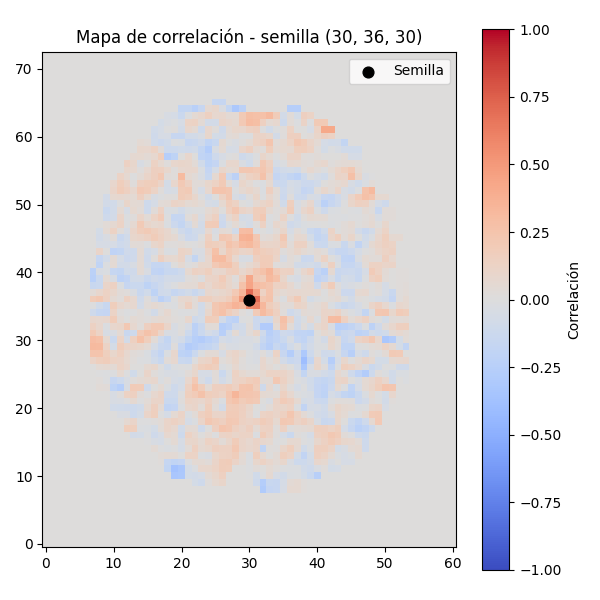

In [42]:
plt.figure(figsize=(6, 6))
plt.imshow(corr_map.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.scatter(x_seed, y_seed, c="black", s=60, label="Semilla")
plt.title(f"Mapa de correlación - semilla ({x_seed}, {y_seed}, {z})")
plt.legend()
plt.tight_layout()
plt.show()

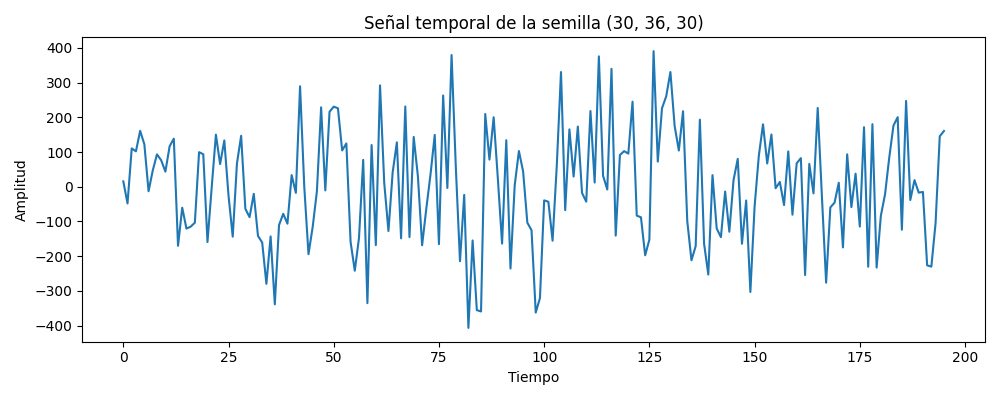

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(seed_signal)
plt.title(f"Señal temporal de la semilla ({x_seed}, {y_seed}, {z})")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

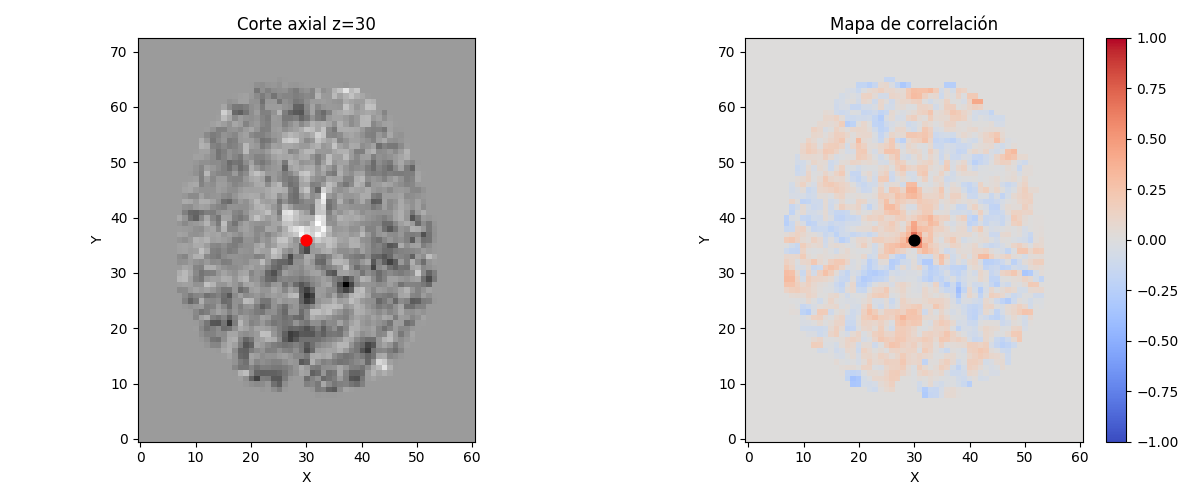

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(data[:, :, z, 0].T, cmap="gray", origin="lower")
axes[0].scatter(x_seed, y_seed, c="red", s=60)
axes[0].set_title(f"Corte axial z={z}")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

im = axes[1].imshow(corr_map.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
axes[1].scatter(x_seed, y_seed, c="black", s=60)
axes[1].set_title("Mapa de correlación")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [45]:
def mostrar_mapa_interactivo(z, t=0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Imagen inicial corte axial
    axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    # Imagen inicial vacía para el mapa
    mapa_inicial = np.zeros((x_dim, y_dim))
    im = axes[1].imshow(mapa_inicial.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
    axes[1].set_title("Haz clic en la imagen")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")

    # Crear colorbar UNA sola vez
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("Correlación")

    def onclick(event):
        if event.inaxes == axes[0] and event.xdata is not None and event.ydata is not None:
            x_seed = int(round(event.xdata))
            y_seed = int(round(event.ydata))

            if 0 <= x_seed < x_dim and 0 <= y_seed < y_dim:
                corr_map, seed_signal = calcular_mapa_correlacion(data, x_seed, y_seed, z)

                # Actualizar corte axial
                axes[0].cla()
                axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
                axes[0].scatter(x_seed, y_seed, c="red", s=60)
                axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
                axes[0].set_xlabel("X")
                axes[0].set_ylabel("Y")

                # Actualizar mapa SIN crear otra colorbar
                axes[1].cla()
                im2 = axes[1].imshow(corr_map.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
                axes[1].scatter(x_seed, y_seed, c="black", s=60)
                axes[1].set_title(f"Mapa de correlación\nSemilla ({x_seed}, {y_seed}, {z})")
                axes[1].set_xlabel("X")
                axes[1].set_ylabel("Y")

                # actualizar la colorbar existente
                cbar.update_normal(im2)

                fig.canvas.draw_idle()

                print(f"Semilla seleccionada: ({x_seed}, {y_seed}, {z})")

    fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show()

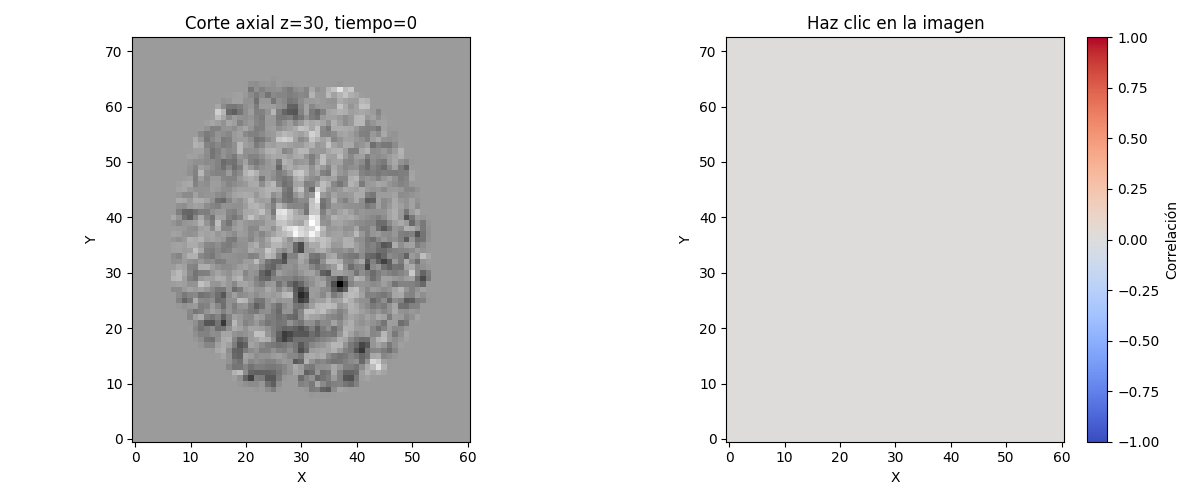

In [46]:
mostrar_mapa_interactivo(z=z_dim // 2, t=0)

In [47]:
widgets.interact(
    mostrar_mapa_interactivo,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.fixed(0)
)

interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

<function __main__.mostrar_mapa_interactivo(z, t=0)>

## PARCELACIÓN

In [48]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import ipywidgets as widgets
from nilearn import datasets
from nilearn.image import resample_to_img

# ── Cargar fMRI (reutiliza si ya está en memoria) ──────────────────────────
try:
    fmri_data
    fmri_img
    print(f'fMRI ya cargado. Shape: {fmri_data.shape}')
except NameError:
    abide = datasets.fetch_abide_pcp(
        data_dir='./data',
        n_subjects=1,
        pipeline='cpac',
        band_pass_filtering=False,
        global_signal_regression=False,
        derivatives=['func_preproc']
    )
    fmri_img  = nib.load(abide.func_preproc[0])
    fmri_data = fmri_img.get_fdata()
    TR = float(fmri_img.header.get_zooms()[3])
    print(f'fMRI cargado. Shape: {fmri_data.shape}, TR={TR}s')

x_dim, y_dim, z_dim, t_dim = fmri_data.shape

# ── Cargar atlas y remuestrear ─────────────────────────────────────────────
atlas     = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_img = atlas.maps

atlas_resampled      = resample_to_img(atlas_img, fmri_img.slicer[:, :, :, 0], interpolation='nearest')
atlas_resampled_data = atlas_resampled.get_fdata()

print(f'Atlas shape: {atlas_resampled_data.shape}')
print(f'Regiones   : {len(atlas.labels)}')

# ── Pre-calcular señal promedio por ROI (orig + filtrada) ─────────────────
# Aseguramos que bandpass_filter esté disponible
try:
    bandpass_filter
    TR
except NameError:
    from scipy.signal import butter, filtfilt
    TR = float(fmri_img.header.get_zooms()[3])
    def bandpass_filter(signal, lowcut=0.01, highcut=0.1, tr=2.0):
        fs  = 1.0 / tr
        nyq = fs / 2.0
        b, a = butter(4, [max(lowcut/nyq, 1e-6), min(highcut/nyq, 0.9999)], btype='band')
        return filtfilt(b, a, signal)

roi_ids_all   = [int(i) for i in np.unique(atlas_resampled_data) if i != 0]
roi_sizes_all = {rid: int(np.sum(atlas_resampled_data == rid)) for rid in roi_ids_all}
MIN_VOXELS    = 100

print('Pre-calculando señales ROI (puede tardar ~30s)...')
roi_signal_cache = {}   # rid -> (sig_orig, sig_filt)
roi_name_map     = {}   # rid -> nombre

for rid in roi_ids_all:
    mask = atlas_resampled_data == rid
    name = atlas.labels[rid - 1] if rid - 1 < len(atlas.labels) else f'ROI_{rid}'
    roi_name_map[rid] = str(name)
    if roi_sizes_all[rid] >= MIN_VOXELS:
        sig = fmri_data[mask, :].mean(axis=0)
        roi_signal_cache[rid] = (sig, bandpass_filter(sig, tr=TR))

print(f'Listo. {len(roi_signal_cache)} ROIs con señal precalculada.')


fMRI cargado. Shape: (61, 73, 61, 196), TR=1.5s
Atlas shape: (61, 73, 61)
Regiones   : 49
Pre-calculando señales ROI (puede tardar ~30s)...
Listo. 47 ROIs con señal precalculada.


C:\Users\crist\AppData\Local\Temp\ipykernel_21904\2324351661.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roi = plt.cm.get_cmap('tab20', n_rois)


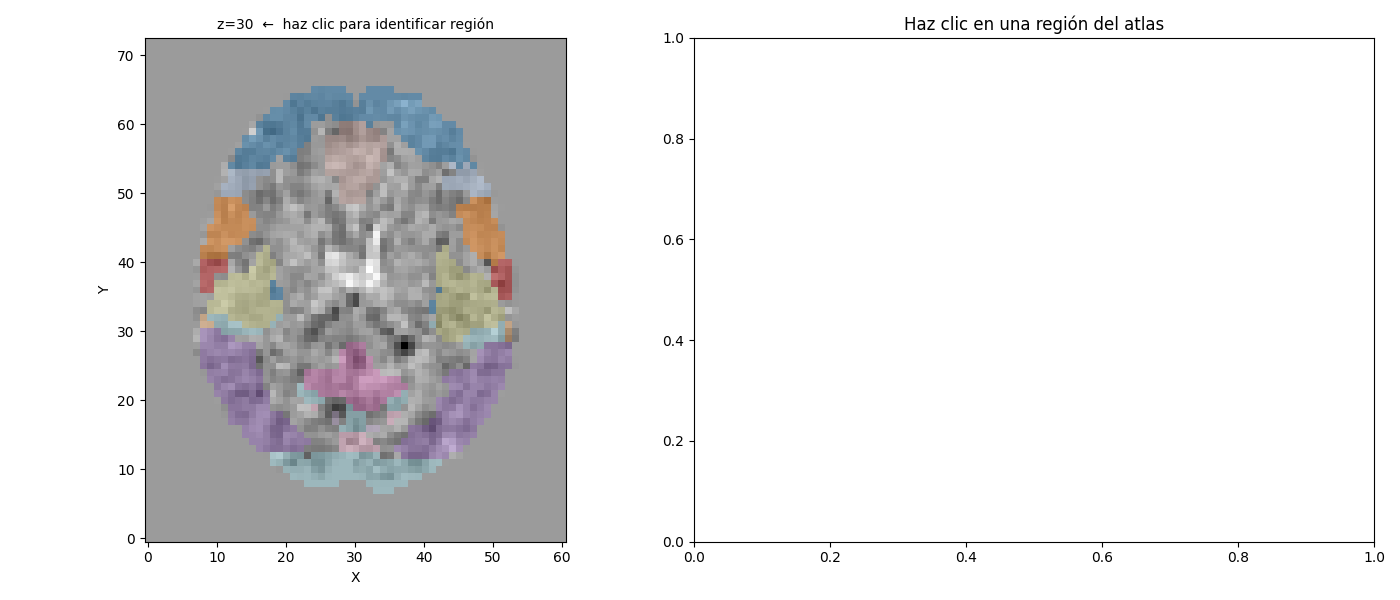

In [49]:
def visor_parcelacion(z_init=None, alpha_atlas=0.45):
    """
    Visor interactivo de parcelación:
      - Slider z      : navega cortes axiales
      - Slider opacity: controla transparencia del overlay del atlas
      - Clic          : identifica la ROI, muestra nombre y señal orig+filtrada
    """
    if z_init is None:
        z_init = z_dim // 2

    n_rois   = len(roi_ids_all)
    cmap_roi = plt.cm.get_cmap('tab20', n_rois)
    state    = {'z': z_init, 'alpha': alpha_atlas, 'roi_sel': None}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ── dibujar cerebro + overlay ──────────────────────────────────────────
    def draw_brain():
        z, alpha, roi_s = state['z'], state['alpha'], state['roi_sel']
        axes[0].cla()

        # Fondo: cerebro en escala de grises
        axes[0].imshow(fmri_data[:, :, z, 0].T, cmap='gray', origin='lower')

        # Overlay: cada ROI con su color
        atlas_slice = atlas_resampled_data[:, :, z].T
        overlay     = np.zeros((*atlas_slice.shape, 4))  # RGBA

        for idx, rid in enumerate(roi_ids_all):
            mask_2d = atlas_slice == rid
            if not mask_2d.any():
                continue
            r, g, b, _ = cmap_roi(idx)
            # ROI seleccionada: más opaca
            a = min(alpha * 1.9, 1.0) if rid == roi_s else alpha
            overlay[mask_2d] = [r, g, b, a]

        axes[0].imshow(overlay, origin='lower')

        # Contorno blanco de la ROI seleccionada
        if roi_s is not None:
            mask_2d = atlas_slice == roi_s
            if mask_2d.any():
                axes[0].contour(mask_2d, levels=[0.5], colors='white', linewidths=1.5)

        nombre = roi_name_map.get(roi_s, '') if roi_s else ''
        titulo = f'z={z}  —  {nombre}' if nombre else f'z={z}  ←  haz clic para identificar región'
        axes[0].set_title(titulo, fontsize=10)
        axes[0].set_xlabel('X')
        axes[0].set_ylabel('Y')

    # ── dibujar señal de la ROI ────────────────────────────────────────────
    def draw_signal(rid):
        axes[1].cla()
        nombre = roi_name_map.get(rid, f'ROI {rid}')
        nvox   = roi_sizes_all.get(rid, 0)

        if rid not in roi_signal_cache:
            axes[1].set_title(f'{nombre}\nROI {rid} — muy pequeña (< {MIN_VOXELS} voxeles)', fontsize=9)
            return

        sig_orig, sig_filt = roi_signal_cache[rid]
        axes[1].plot(sig_orig, color='steelblue', lw=1.2, alpha=0.7, label='Original')
        axes[1].plot(sig_filt, color='tomato',    lw=1.4, alpha=0.9, label='Filtrada (0.01–0.1 Hz)')
        axes[1].set_title(f'{nombre}\nROI {rid}  —  {nvox} voxeles', fontsize=9)
        axes[1].set_xlabel('Tiempo (volúmenes)')
        axes[1].set_ylabel('Amplitud')
        axes[1].legend(fontsize=8)

    # ── evento clic ───────────────────────────────────────────────────────
    def on_click(event):
        if event.inaxes != axes[0] or event.xdata is None:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        z = state['z']
        if not (0 <= x < x_dim and 0 <= y < y_dim):
            return

        rid = int(atlas_resampled_data[x, y, z])
        if rid == 0:
            print(f'Clic en ({x}, {y}, {z}) — fuera del atlas (fondo)')
            return

        state['roi_sel'] = rid
        nombre = roi_name_map.get(rid, f'ROI {rid}')
        nvox   = roi_sizes_all.get(rid, 0)
        print(f'ROI {rid}: {nombre}  |  {nvox} voxeles  |  voxel ({x}, {y}, {z})')

        draw_brain()
        draw_signal(rid)
        fig.canvas.draw_idle()

    # ── sliders ───────────────────────────────────────────────────────────
    sl_z = widgets.IntSlider(
        value=z_init, min=0, max=z_dim - 1, step=1,
        description='z (corte):',
        style={'description_width': 'auto'},
        layout=widgets.Layout(width='420px')
    )
    sl_alpha = widgets.FloatSlider(
        value=alpha_atlas, min=0.0, max=1.0, step=0.05,
        description='Opacidad atlas:',
        style={'description_width': 'auto'},
        layout=widgets.Layout(width='420px')
    )

    def on_z(change):
        state['z'] = change['new']
        draw_brain()
        fig.canvas.draw_idle()

    def on_alpha(change):
        state['alpha'] = change['new']
        draw_brain()
        fig.canvas.draw_idle()

    sl_z.observe(on_z,     names='value')
    sl_alpha.observe(on_alpha, names='value')
    fig.canvas.mpl_connect('button_press_event', on_click)

    draw_brain()
    axes[1].set_title('Haz clic en una región del atlas')
    plt.tight_layout()
    plt.show()
    display(widgets.VBox([sl_z, sl_alpha]))


visor_parcelacion()


## CONECTIVIDAD

In [50]:
%matplotlib widget

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from nilearn import datasets
from nilearn.image import resample_to_img

In [52]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

fmri_img = nib.load(fmri_path)
fmri_data = fmri_img.get_fdata()

print("fMRI shape:", fmri_data.shape)

fMRI shape: (61, 73, 61, 196)


In [53]:
# Cargar atlas si no está en memoria (hace esta sección autocontenida)
try:
    atlas_img
    atlas
    print('Atlas ya cargado.')
except NameError:
    atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
    atlas_img = atlas.maps
    print('Atlas cargado desde fetch.')

atlas_resampled = resample_to_img(
    atlas_img,
    fmri_img.slicer[:, :, :, 0],
    interpolation='nearest'
)
atlas_resampled_data = atlas_resampled.get_fdata()
print('Atlas remuestreado shape:', atlas_resampled_data.shape)


Atlas ya cargado.
Atlas remuestreado shape: (61, 73, 61)


In [54]:
roi_ids = [int(i) for i in np.unique(atlas_resampled_data) if i != 0]

print("Primeros 20 ROI IDs:")
print(roi_ids[:20])
print("Cantidad total de ROIs:", len(roi_ids))

Primeros 20 ROI IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Cantidad total de ROIs: 48


In [55]:
roi_sizes = {}

for roi_id in roi_ids:
    mask = atlas_resampled_data == roi_id
    roi_sizes[roi_id] = int(np.sum(mask))

print("Primeras 20 ROIs con tamaño:")
for roi_id in roi_ids[:20]:
    print(f"ROI {roi_id}: {roi_sizes[roi_id]} voxeles")

Primeras 20 ROIs con tamaño:
ROI 1: 4546 voxeles
ROI 2: 682 voxeles
ROI 3: 1509 voxeles
ROI 4: 1577 voxeles
ROI 5: 335 voxeles
ROI 6: 410 voxeles
ROI 7: 2546 voxeles
ROI 8: 1418 voxeles
ROI 9: 151 voxeles
ROI 10: 541 voxeles
ROI 11: 241 voxeles
ROI 12: 763 voxeles
ROI 13: 590 voxeles
ROI 14: 187 voxeles
ROI 15: 568 voxeles
ROI 16: 436 voxeles
ROI 17: 2024 voxeles
ROI 18: 866 voxeles
ROI 19: 498 voxeles
ROI 20: 709 voxeles


In [56]:
min_voxels = 100
selected_rois = [roi_id for roi_id in roi_ids if roi_sizes[roi_id] >= min_voxels]

print("Cantidad de ROIs seleccionadas:", len(selected_rois))
print("Primeras 20 seleccionadas:", selected_rois[:20])

Cantidad de ROIs seleccionadas: 47
Primeras 20 seleccionadas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [57]:
roi_signals = []
roi_names = []

for roi_id in selected_rois:
    mask = atlas_resampled_data == roi_id
    signal = fmri_data[mask, :].mean(axis=0)
    roi_signals.append(signal)
    
    # nombre de la ROI
    if roi_id - 1 < len(atlas.labels):
        roi_names.append(str(atlas.labels[roi_id - 1]))
    else:
        roi_names.append(f"ROI_{roi_id}")

roi_signals = np.array(roi_signals).T   # tiempo x ROI

print("Shape matriz tiempo x ROI:", roi_signals.shape)

Shape matriz tiempo x ROI: (196, 47)


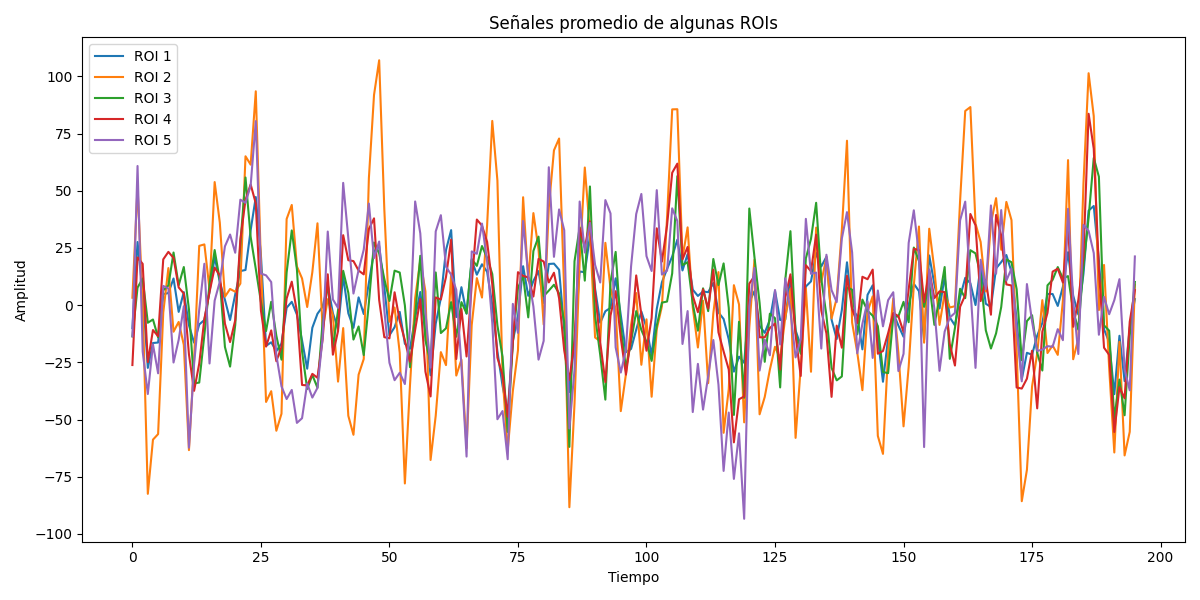

In [58]:
plt.figure(figsize=(12, 6))

for i in range(min(5, roi_signals.shape[1])):
    plt.plot(roi_signals[:, i], label=f"ROI {selected_rois[i]}")

plt.title("Señales promedio de algunas ROIs")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

Filtrando 47 ROIs con TR=1.5s...
Shape señales filtradas: (196, 47)


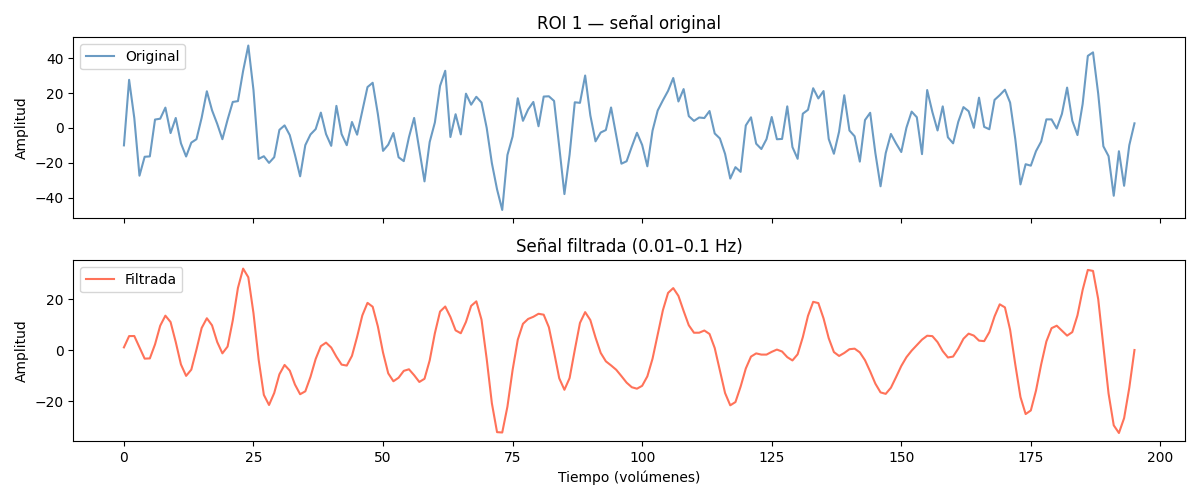

In [59]:
# Filtrar señales de cada ROI antes de calcular conectividad
# Esto es estándar en fMRI en reposo (band-pass 0.01–0.1 Hz)
try:
    bandpass_filter
    TR
except NameError:
    from scipy.signal import butter, filtfilt
    import nibabel as nib
    img_tmp = nib.load(abide.func_preproc[0])
    TR = img_tmp.header.get_zooms()[3]

    def bandpass_filter(signal, lowcut=0.01, highcut=0.1, tr=2.0):
        fs = 1.0 / tr
        nyq = fs / 2.0
        low = max(lowcut / nyq, 1e-6)
        high = min(highcut / nyq, 0.9999)
        b, a = butter(4, [low, high], btype='band')
        return filtfilt(b, a, signal)

print(f'Filtrando {roi_signals.shape[1]} ROIs con TR={TR}s...')
roi_signals_filt = np.array([
    bandpass_filter(roi_signals[:, i], tr=TR)
    for i in range(roi_signals.shape[1])
]).T  # tiempo x ROI

print('Shape señales filtradas:', roi_signals_filt.shape)

# Visualizar comparación en la primera ROI
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(roi_signals[:, 0], color='steelblue', alpha=0.8, label='Original')
axes[0].set_ylabel('Amplitud')
axes[0].legend()
axes[0].set_title(f'ROI {selected_rois[0]} — señal original')
axes[1].plot(roi_signals_filt[:, 0], color='tomato', alpha=0.9, label='Filtrada')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (volúmenes)')
axes[1].legend()
axes[1].set_title('Señal filtrada (0.01–0.1 Hz)')
plt.tight_layout()
plt.show()


In [60]:
# Matriz de correlación sobre señales FILTRADAS
corr_matrix = np.corrcoef(roi_signals_filt.T)

print('Shape matriz ROI x ROI:', corr_matrix.shape)


Shape matriz ROI x ROI: (47, 47)


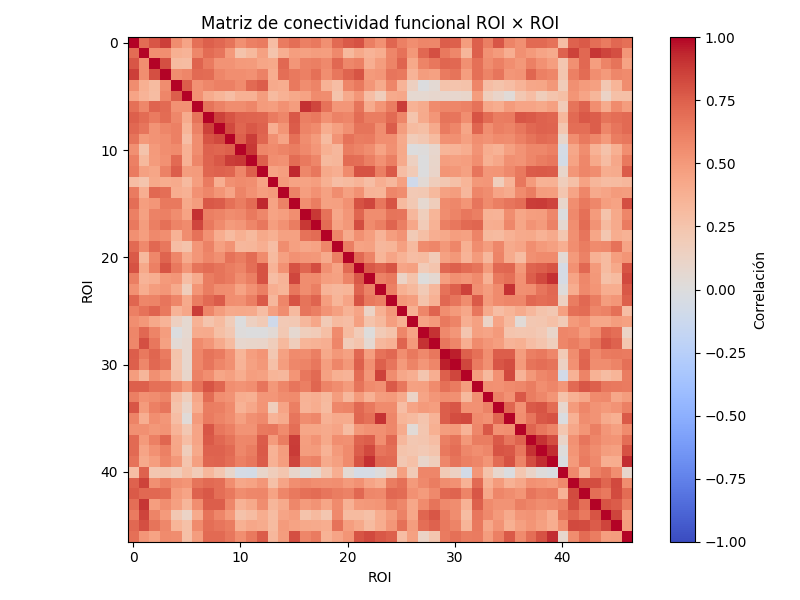

In [61]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.title("Matriz de conectividad funcional ROI × ROI")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

In [62]:
print("Diagonal:")
print(np.diag(corr_matrix))

print("\nPrimer bloque 5x5:")
print(corr_matrix[:5, :5])

Diagonal:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Primer bloque 5x5:
[[1.         0.70048983 0.7837252  0.86199242 0.56198594]
 [0.70048983 1.         0.5520012  0.55372851 0.38273911]
 [0.7837252  0.5520012  1.         0.81064973 0.30938048]
 [0.86199242 0.55372851 0.81064973 1.         0.56222444]
 [0.56198594 0.38273911 0.30938048 0.56222444 1.        ]]


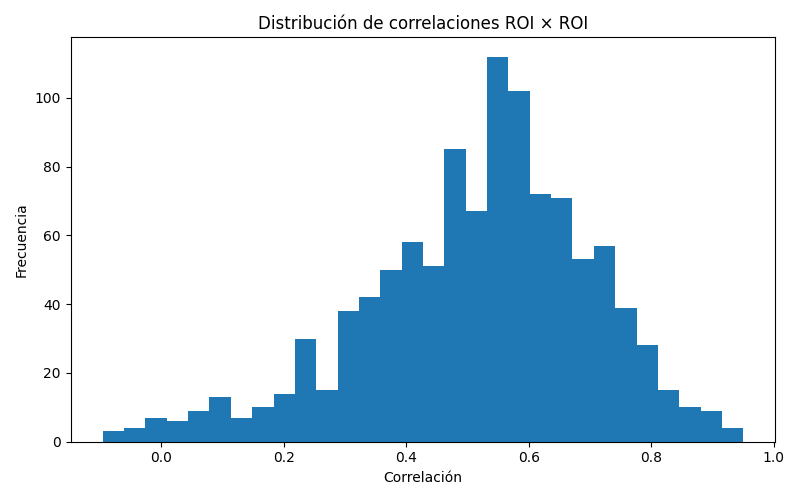

In [63]:
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]

plt.figure(figsize=(8, 5))
plt.hist(upper_tri, bins=30)
plt.title("Distribución de correlaciones ROI × ROI")
plt.xlabel("Correlación")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

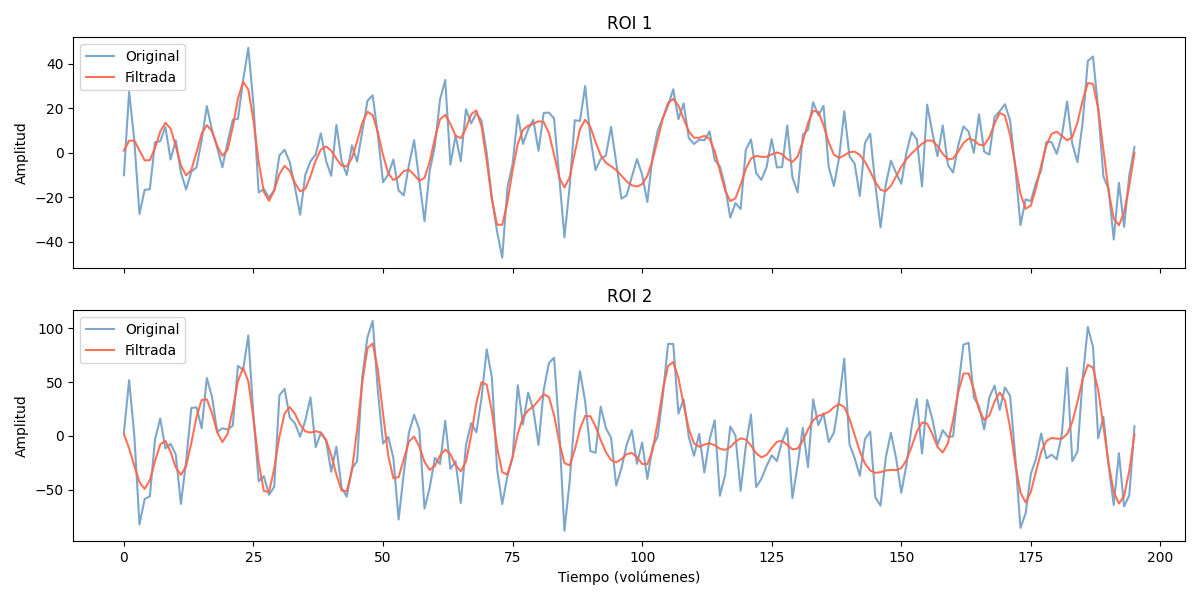

Correlación (filtrada) entre ROI 1 y ROI 2: 0.7005


In [64]:
i = 0
j = 1

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(roi_signals[:, i], color='steelblue', alpha=0.7, label='Original')
axes[0].plot(roi_signals_filt[:, i], color='tomato', alpha=0.9, label='Filtrada')
axes[0].set_title(f'ROI {selected_rois[i]}')
axes[0].set_ylabel('Amplitud')
axes[0].legend()
axes[1].plot(roi_signals[:, j], color='steelblue', alpha=0.7, label='Original')
axes[1].plot(roi_signals_filt[:, j], color='tomato', alpha=0.9, label='Filtrada')
axes[1].set_title(f'ROI {selected_rois[j]}')
axes[1].set_ylabel('Amplitud')
axes[1].set_xlabel('Tiempo (volúmenes)')
axes[1].legend()
plt.tight_layout()
plt.show()

print(f'Correlación (filtrada) entre ROI {selected_rois[i]} y ROI {selected_rois[j]}: {corr_matrix[i, j]:.4f}')


In [65]:
import os

os.makedirs('resultados', exist_ok=True)

np.save('resultados/roi_signals_orig.npy', roi_signals)
np.save('resultados/roi_signals_filt.npy', roi_signals_filt)
np.save('resultados/corr_matrix_roi.npy', corr_matrix)
np.save('resultados/selected_rois.npy', np.array(selected_rois))

print('Resultados guardados:')
print('  - roi_signals_orig.npy  (señales crudas, tiempo x ROI)')
print('  - roi_signals_filt.npy  (señales filtradas, tiempo x ROI)')
print('  - corr_matrix_roi.npy   (matriz de conectividad ROI x ROI)')
print('  - selected_rois.npy     (IDs de ROIs usadas)')


Resultados guardados:
  - roi_signals_orig.npy  (señales crudas, tiempo x ROI)
  - roi_signals_filt.npy  (señales filtradas, tiempo x ROI)
  - corr_matrix_roi.npy   (matriz de conectividad ROI x ROI)
  - selected_rois.npy     (IDs de ROIs usadas)


C:\Users\crist\AppData\Local\Temp\ipykernel_21904\655375360.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_roi  = plt.cm.get_cmap('tab20', n_rois)


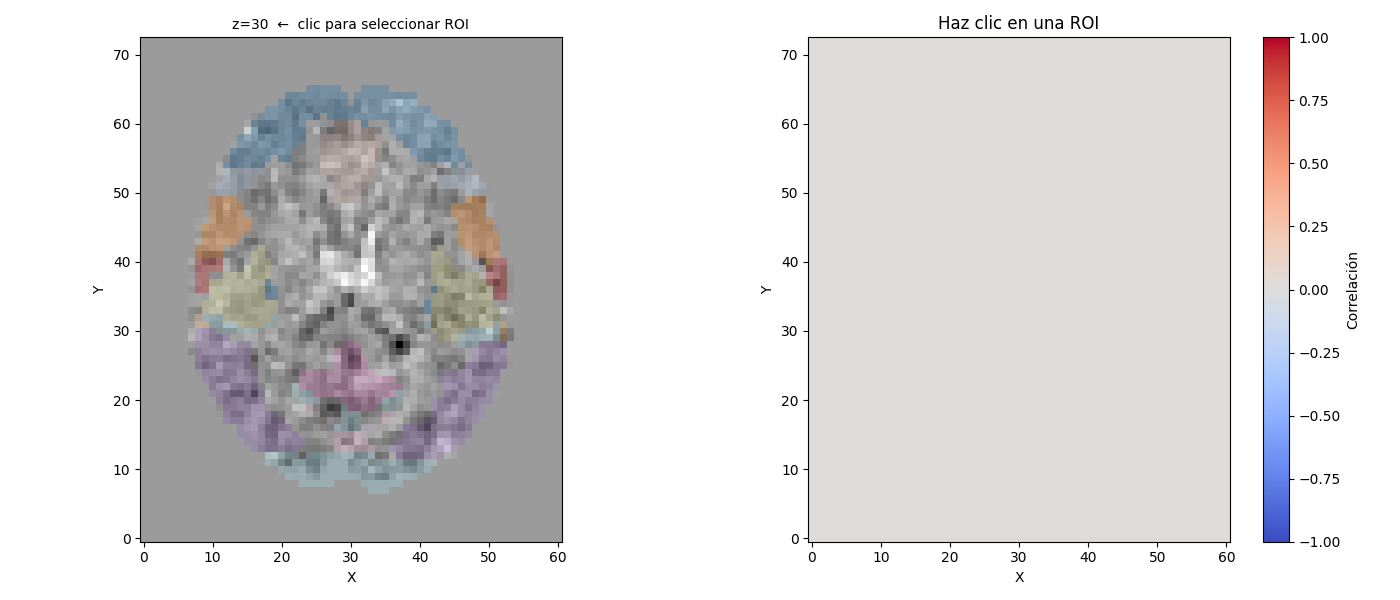

In [66]:
# ── Mapa de correlación 3D con semilla por ROI del atlas ──────────────────

def calcular_mapa_correlacion_3D_roi(data, seed_signal):
    """
    Igual que la versión voxel, pero la semilla es la señal
    promedio de una ROI entera (ya viene calculada).
    """
    n_voxels = x_dim * y_dim * z_dim
    all_signals = data.reshape(n_voxels, t_dim)

    seed_norm = seed_signal - seed_signal.mean()
    seed_std  = seed_signal.std()

    all_mean = all_signals.mean(axis=1, keepdims=True)
    all_std  = all_signals.std(axis=1)

    valid = all_std > 0
    corr_flat = np.zeros(n_voxels)
    corr_flat[valid] = (
        ((all_signals[valid] - all_mean[valid]) @ seed_norm)
        / (all_std[valid] * seed_std * t_dim)
    )

    return corr_flat.reshape(x_dim, y_dim, z_dim)


def visor_conectividad_atlas(z_view=None, alpha=0.3):
    """
    Clic en una ROI del atlas → calcula mapa de correlación 3D
    usando la señal promedio de esa ROI como semilla.
    Podés navegar todos los cortes del mapa resultante.
    """
    if z_view is None:
        z_view = z_dim // 2

    n_rois    = len(roi_ids_all)
    cmap_roi  = plt.cm.get_cmap('tab20', n_rois)
    state     = {'z': z_view, 'corr_3D': None, 'roi_sel': None}

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # colorbar fija para el mapa de correlación
    mapa_vacio = np.zeros((x_dim, y_dim))
    im_corr = axes[1].imshow(mapa_vacio.T, cmap='coolwarm',
                             origin='lower', vmin=-1, vmax=1)
    cbar = fig.colorbar(im_corr, ax=axes[1])
    cbar.set_label('Correlación')

    def draw_atlas():
        z = state['z']
        axes[0].cla()
        axes[0].imshow(fmri_data[:, :, z, 0].T, cmap='gray', origin='lower')

        atlas_slice = atlas_resampled_data[:, :, z].T
        overlay = np.zeros((*atlas_slice.shape, 4))

        for idx, rid in enumerate(roi_ids_all):
            mask_2d = atlas_slice == rid
            if not mask_2d.any():
                continue
            r, g, b, _ = cmap_roi(idx)
            a = min(alpha * 2, 1.0) if rid == state['roi_sel'] else alpha
            overlay[mask_2d] = [r, g, b, a]

        axes[0].imshow(overlay, origin='lower')

        nombre = roi_name_map.get(state['roi_sel'], '') if state['roi_sel'] else ''
        titulo = f"z={z}  —  {nombre}" if nombre else f"z={z}  ←  clic para seleccionar ROI"
        axes[0].set_title(titulo, fontsize=10)
        axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')

    def draw_corr():
        z = state['z']
        axes[1].cla()

        if state['corr_3D'] is None:
            im2 = axes[1].imshow(np.zeros((x_dim, y_dim)).T, cmap='coolwarm',
                                 origin='lower', vmin=-1, vmax=1)
            axes[1].set_title('Haz clic en una ROI')
        else:
            im2 = axes[1].imshow(state['corr_3D'][:, :, z].T, cmap='coolwarm',
                                 origin='lower', vmin=-1, vmax=1)
            nombre = roi_name_map.get(state['roi_sel'], '')
            axes[1].set_title(f"Conectividad desde: {nombre}\nz={z}", fontsize=9)

        axes[1].set_xlabel('X'); axes[1].set_ylabel('Y')
        cbar.update_normal(im2)

    def onclick(event):
        if event.inaxes != axes[0] or event.xdata is None:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        z = state['z']
        if not (0 <= x < x_dim and 0 <= y < y_dim):
            return

        rid = int(atlas_resampled_data[x, y, z])
        if rid == 0:
            print('Clic fuera del atlas (fondo)')
            return

        if rid not in roi_signal_cache:
            print(f'ROI {rid} muy pequeña, sin señal precalculada')
            return

        state['roi_sel'] = rid
        nombre = roi_name_map.get(rid, f'ROI {rid}')
        print(f'Semilla: {nombre} (ROI {rid}) — calculando mapa 3D...')

        # señal filtrada de la ROI como semilla
        _, sig_filt = roi_signal_cache[rid]
        state['corr_3D'] = calcular_mapa_correlacion_3D_roi(fmri_data, sig_filt)

        print('Listo.')
        draw_atlas()
        draw_corr()
        fig.canvas.draw_idle()

    # sliders
    sl_z = widgets.IntSlider(
        value=z_view, min=0, max=z_dim-1, step=1,
        description='z (corte):',
        style={'description_width': 'auto'},
        layout=widgets.Layout(width='420px')
    )

    def on_z(change):
        state['z'] = change['new']
        draw_atlas()
        draw_corr()
        fig.canvas.draw_idle()

    sl_z.observe(on_z, names='value')
    fig.canvas.mpl_connect('button_press_event', onclick)

    draw_atlas()
    draw_corr()
    plt.tight_layout()
    plt.show()
    display(widgets.VBox([sl_z]))


visor_conectividad_atlas()

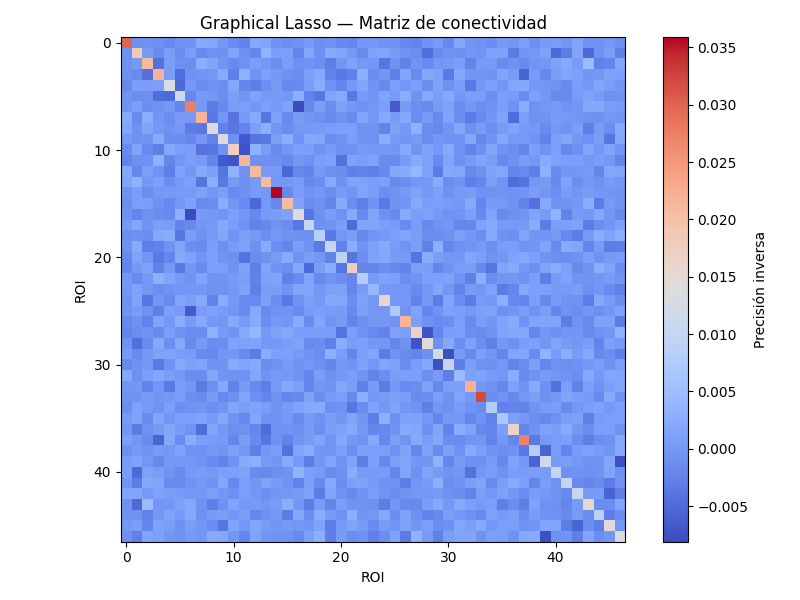

Guardado: gl_matrix.npy


In [68]:
## GRAPHICAL LASSO (Conectividad con precisión inversa)

from nilearn.connectome import ConnectivityMeasure

# Graphical Lasso via Nilearn
gl_measure = ConnectivityMeasure(kind='precision')
gl_matrix = gl_measure.fit_transform([roi_signals_filt])[0]

# Visualizar
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.imshow(gl_matrix, cmap='coolwarm')
plt.colorbar(label='Precisión inversa')
plt.title('Graphical Lasso — Matriz de conectividad')
plt.xlabel('ROI'); plt.ylabel('ROI')
plt.tight_layout()
plt.show()

# Guardar
import numpy as np
np.save('resultados/gl_matrix.npy', gl_matrix)
print('Guardado: gl_matrix.npy')